## Google Trends Data: Resampling and Visualizing time series

on this day ill explore time series datasets, clean and resample dates, work with pandas date time indexes, create time series line chart..

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df_tesla = pd.read_csv("TESLA Search Trend vs Price.csv")
df_btc = pd.read_csv("Bitcoin Search Trend.csv")
df_unemployment = pd.read_csv("UE Benefits Search vs UE Rate 2004-19.csv")

In [8]:
df_tesla.head()

,MONTH,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
0,2010-06-01,3,4.766
1,2010-07-01,3,3.988
2,2010-08-01,2,3.896
3,2010-09-01,2,4.082
4,2010-10-01,2,4.368


In [9]:
df_tesla.columns

Index(['MONTH', 'TSLA_WEB_SEARCH', 'TSLA_USD_CLOSE'], dtype='object')

In [10]:
df_tesla.shape

(124, 3)

In [11]:
df_tesla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MONTH            124 non-null    object 
 1   TSLA_WEB_SEARCH  124 non-null    int64  
 2   TSLA_USD_CLOSE   124 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 3.0+ KB


Data Cleaning — Resampling Time-Series Data

Convert the date column into a proper Pandas datetime:

In [12]:
df_tesla.MONTH = pd.to_datetime(df_tesla.MONTH)

In [13]:
df_tesla.head()

,MONTH,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
0,2010-06-01,3,4.766
1,2010-07-01,3,3.988
2,2010-08-01,2,3.896
3,2010-09-01,2,4.082
4,2010-10-01,2,4.368


In [14]:
df_tesla.set_index("MONTH", inplace=True)

can convert it into monthly, quaterly or yearly

In [15]:
df_tesla.resample("ME").mean()

,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
MONTH,,
2010-06-30,3.0,4.766000
2010-07-31,3.0,3.988000
2010-08-31,2.0,3.896000
2010-09-30,2.0,4.082000
2010-10-31,2.0,4.368000
...,...,...
2020-05-31,16.0,167.000000
2020-06-30,17.0,215.962006
2020-07-31,24.0,286.152008


In [16]:
df_tesla.resample("YE").mean()

,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
MONTH,,
2010-12-31,2.285714,4.784571
2011-12-31,2.333333,5.509667
2012-12-31,3.000000,6.244667
2013-12-31,5.083333,21.727333
2014-12-31,6.166667,45.578333
2015-12-31,7.833333,46.360500
2016-12-31,9.333333,42.347000
2017-12-31,11.250000,62.818500
2018-12-31,12.500000,62.837499


Data Visualization — Tesla Line Chart

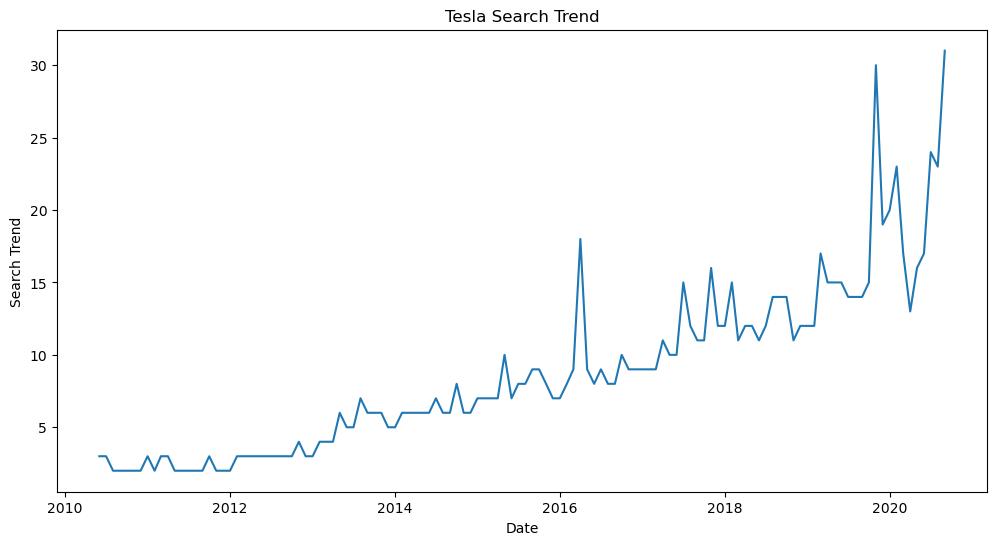

In [ ]:
# this shows how series for tesla changes over time
plt.figure(figsize=(12, 6))

plt.plot(
    df_tesla.index,
    df_tesla["TSLA_WEB_SEARCH"]
)

plt.xlabel("Date")
plt.ylabel("Search Trend")
plt.title("Tesla Search Trend")

plt.show()

Locators and DateFormatters

In [18]:
import matplotlib.dates as mdates

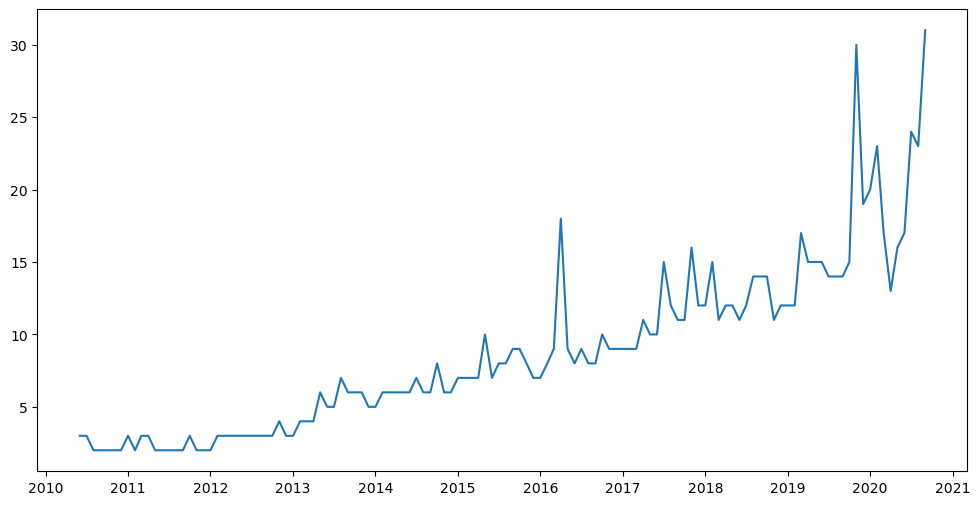

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_tesla.index,
    df_tesla["TSLA_WEB_SEARCH"]
)

plt.gca().xaxis.set_major_locator(
    mdates.YearLocator()
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

plt.show()

Bitcoin price and search volume

In [20]:
df_btc.head()

,MONTH,BTC_NEWS_SEARCH
0,2014-09,5
1,2014-10,4
2,2014-11,4
3,2014-12,4
4,2015-01,5


In [21]:
df_btc.MONTH = pd.to_datetime(df_btc.MONTH)

In [22]:
df_btc.set_index("MONTH", inplace=True)

plot the search

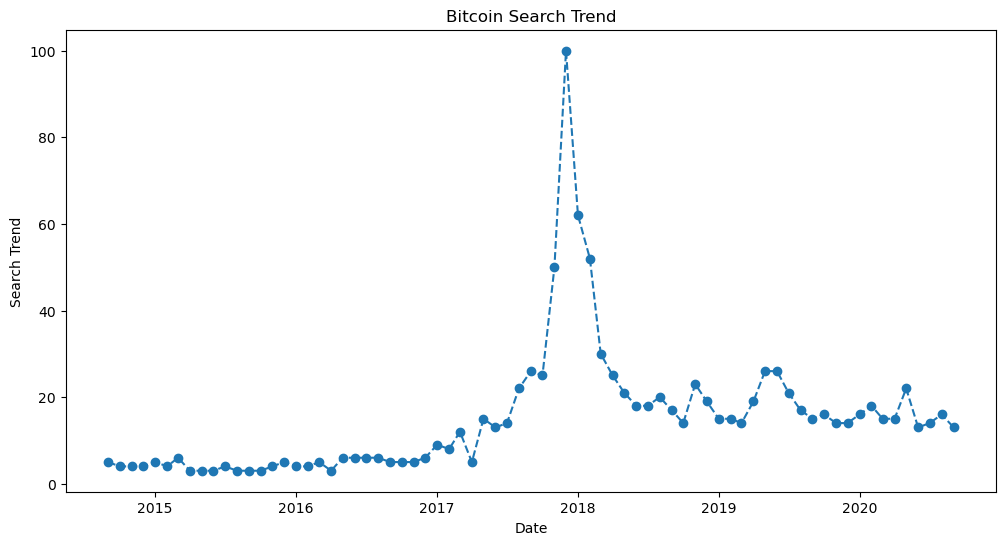

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_btc.index,
    df_btc["BTC_NEWS_SEARCH"],
    linestyle="--",
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Search Trend")
plt.title("Bitcoin Search Trend")

plt.show()

Data Visualization - Unemployment: How to use grids

explore the unemployment

In [24]:
df_unemployment.head()

,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
0,2004-01,34,5.7
1,2004-02,33,5.6
2,2004-03,25,5.8
3,2004-04,29,5.6
4,2004-05,23,5.6


In [25]:
df_unemployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   MONTH                   181 non-null    object 
 1   UE_BENEFITS_WEB_SEARCH  181 non-null    int64  
 2   UNRATE                  181 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.4+ KB


In [26]:
df_unemployment.MONTH = pd.to_datetime(
    df_unemployment.MONTH
)

In [27]:
df_unemployment.set_index(
    "MONTH",
    inplace=True
)

plot the unemploymet rate

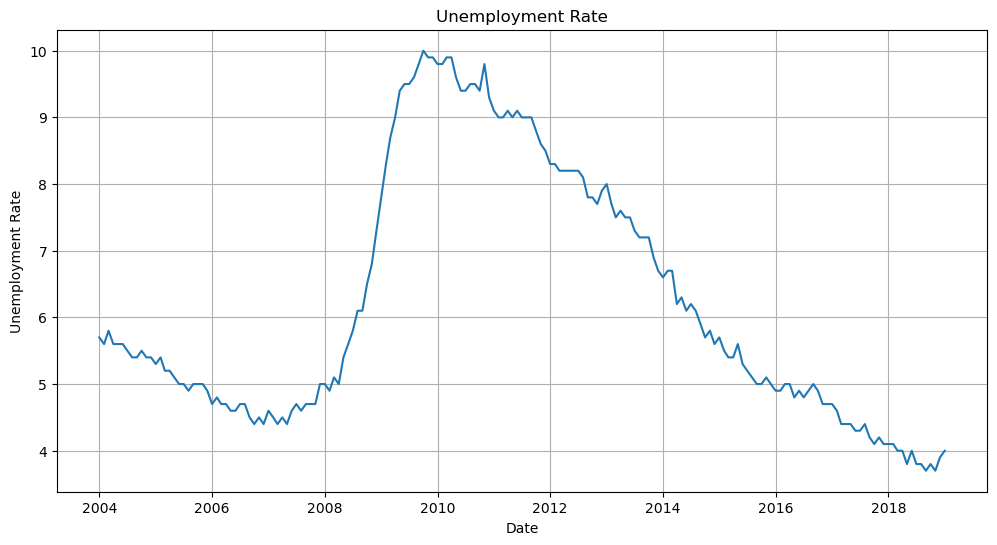

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_unemployment.index,
    df_unemployment["UNRATE"]
)

plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.title("Unemployment Rate")

plt.grid()

plt.show()